# **Exercise - Implement an End to End CNN Model for Image Classification Task**

**1. Load and visualize images from a dataset stored in directories, where each subdirec-
tory represents a class**

Classes found: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


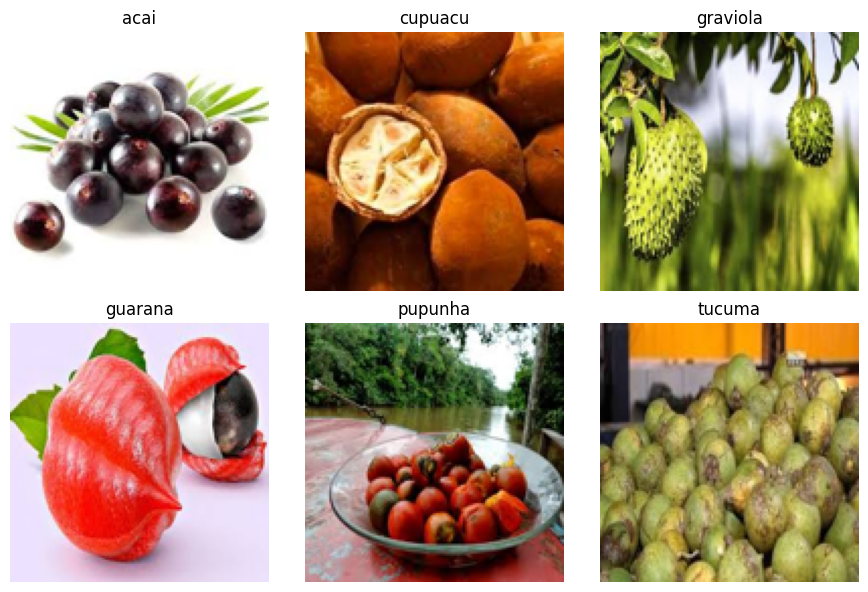

In [281]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

train_dir = "/content/drive/MyDrive/SEM6_AI/Week6/FruitinAmazon/FruitinAmazon/train"
img_width, img_height = 128, 128

class_names = sorted(os.listdir(train_dir))
print("Classes found:", class_names)

images = []
labels = []

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    all_images = [f for f in os.listdir(class_path) if f.lower().endswith(('.jpg','.jpeg','.png'))]
    random_img_name = random.choice(all_images)
    img_path = os.path.join(class_path, random_img_name)

    img = Image.open(img_path).convert("RGB")
    img = img.resize((img_width, img_height))  # Optional resize
    images.append(np.array(img))
    labels.append(class_name)

num_classes = len(class_names)
cols = (num_classes + 1) // 2  # number of columns
fig, axes = plt.subplots(2, cols, figsize=(3*cols, 6))

for i, ax in enumerate(axes.flat):
    if i < num_classes:
        ax.imshow(images[i])
        ax.set_title(labels[i])
    ax.axis('off')

plt.tight_layout()
plt.show()

**2. Check for Corrupted Image**

In [282]:
corrupted_images = []

for class_name in os.listdir(train_dir):
    class_path = os.path.join(train_dir, class_name)
    if not os.path.isdir(class_path):
        continue  # skip non-folder files

    for filename in os.listdir(class_path):
        if not filename.lower().endswith(('.jpg','.jpeg','.png')):
            continue

        img_path = os.path.join(class_path, filename)
        try:
            # Try to open the image
            with Image.open(img_path) as img:
                img.verify()  # Verify checks for corruption
        except (IOError, SyntaxError) as e:
            # Image is corrupted → remove and log it
            corrupted_images.append(img_path)
            os.remove(img_path)
            print(f"Removed corrupted image: {img_path}")

if not corrupted_images:
    print("No corrupted images found.")
else:
    print(f"Total corrupted images removed: {len(corrupted_images)}")

No corrupted images found.


# **Task 2 - Loading and Preprocessing Image Data in keras**

**Interpolation**- When you resize an image, some pixels need to be added or removed to fit the new size (img_height x img_width). Interpolation determines how new pixel values are calculated.

**nearest (Nearest Neighbor Interpolation)**- Each new pixel takes the value of the nearest original pixel.

In [283]:
import tensorflow as tf

# Define image size and batch size
img_height = 128 # Example image height
img_width = 128 # Example image width
batch_size = 32
validation_split = 0.2 # 80% training, 20% validation

# Create a preprocessing layer for normalization
rescale = tf.keras.layers.Rescaling(1./255) # Normalize pixel values to [0, 1]

# Create training dataset with normalization
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
  train_dir,
  labels='inferred',   # Automatically infers labels from folder names
  label_mode='int',    # Labels will be integers (0,1,2,...)
  image_size=(img_height, img_width),  # Resize all images
  interpolation='nearest',
  batch_size=batch_size,
  shuffle=True,
  validation_split=validation_split,
  subset='training',   # Use the training portion
  seed=123 #ensures that these random operations always produce the same images in training & validation set each time you run the code.
  )

# Apply the normalization (Rescaling) to the dataset
train_ds = train_ds.map(lambda x, y: (rescale(x), y))

# Create validation dataset with normalization
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
  train_dir,
  labels='inferred',
  label_mode='int',
  image_size=(img_height, img_width),
  interpolation='nearest',
  batch_size=batch_size,
  shuffle=False,
  validation_split=validation_split,
  subset='validation',
  seed=123
  )

# Apply the normalization (Rescaling) to the validation dataset
val_ds = val_ds.map(lambda x, y: (rescale(x), y))

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.


**Data Augmentation**

In [284]:
from tensorflow.keras import layers

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.2)
])

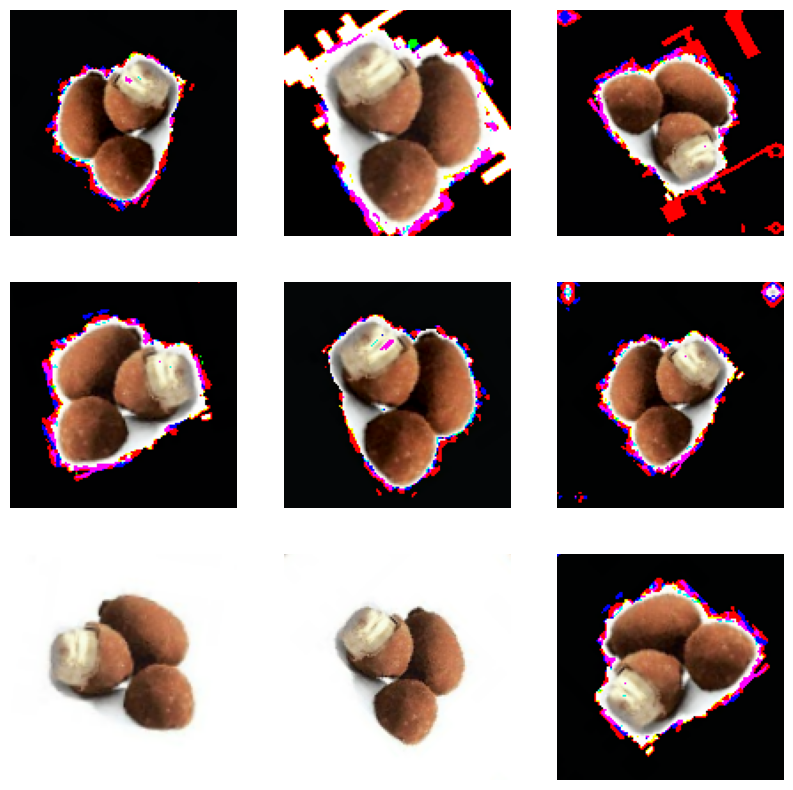

In [285]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
for images, _ in train_ds.take(1):
  for i in range(9):
    augmented_images = data_augmentation(images)
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(np.array(augmented_images[0] * 255).astype("uint8"))
    plt.axis("off")

# **Task 3 - Implement a CNN Model**

In [286]:
# import tensorflow as tf
# from tensorflow.keras import layers, models

# model = models.Sequential([
#     layers.Input(shape=(128, 128, 3)),

#     # Data augmentation applied using Lambda layer
#     *data_augmentation_layers,

#     # Rescaling layer to normalize pixel values
#     layers.Rescaling(1./255),

#     # First Convolutional Block
#     layers.Conv2D(32, (3, 3), padding='same', activation=None),
#     layers.BatchNormalization(),
#     layers.Activation('relu'),
#     layers.MaxPooling2D((2, 2)),
#     layers.Dropout(0.25),

#     # Second Convolutional Block
#     layers.Conv2D(32, (3, 3), padding='same', activation=None),
#     layers.BatchNormalization(),
#     layers.Activation('relu'),
#     layers.MaxPooling2D((2, 2)),
#     layers.Dropout(0.25),

#     # Fully Connected Network
#     layers.Flatten(),                          # Flatten conv output → 1D vecto

#     # First Hidden Layer
#     layers.Dense(128, activation=None),
#     layers.BatchNormalization(),
#     layers.Activation('relu'),
#     layers.Dropout(0.25),

#     # Second Hidden Layer
#     layers.Dense(64, activation=None),
#     layers.BatchNormalization(),
#     layers.Activation('relu'),
#     layers.Dropout(0.25),

#     # Output layer
#     layers.Dense(num_classes, activation='softmax')  # Output Layer: one neuron per class
# ])

In [287]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.models import Model
import tensorflow as tf

# Load the VGG16 model pre-trained on ImageNet, without the top classification layer
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(128, 128, 3))

# Freeze the layers of the base model
for layer in base_model.layers:
  layer.trainable = False

inputs = tf.keras.Input(shape=(128, 128, 3))

# Add custom layers on top of the pre-trained model
x = data_augmentation(inputs)
x = base_model(x, training=False)

x = GlobalAveragePooling2D()(x) # Reduces dimensions (height, width) to a single vector per image

x = Dense(128)(x) # Fully connected layer with 1024 neurons
x = BatchNormalization()(x)
x = tf.keras.layers.Activation('relu')(x)
x = Dropout(0.2)(x)

x = Dense(64)(x)
x = tf.keras.layers.Activation('relu')(x)

output = Dense(num_classes, activation='softmax')(x) # Output layer for 10 classes (with softmax for multi-class classification)

# Create the final model
model = Model(inputs=inputs, outputs=output)


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


# **Task 4 - Compile the Model**

In [288]:
# model.compile(optimizer="adam",
#   loss="sparse_categorical_crossentropy",
#   metrics=["accuracy"])

# # Summary of the model
# model.summary()

In [289]:
from tensorflow.keras.optimizers import Adam

# base_model.trainable = False

# Compile the model
model.compile(
    optimizer=Adam(),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'])

# **Task 5 - Train the Model**

In [290]:
from tensorflow import keras
epochs = 30

# Callbacks
callbacks = [
  keras.callbacks.ModelCheckpoint(
    filepath="best_model.keras",   # save the model to this file
    monitor='val_accuracy',        # watch validation accuracy
    save_best_only=True,           # only save if val_accuracy improved
    mode='max',                    # higher val_accuracy = better
),
  keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=15,
    restore_best_weights=True,     # go back to best epoch's weights when stopped
    verbose=1
)
]

history = model.fit(
  train_ds,
  epochs=epochs,
  validation_data=val_ds,
  callbacks=callbacks,
)

Epoch 1/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.1944 - loss: 2.1594 - val_accuracy: 0.6111 - val_loss: 1.0616
Epoch 2/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 397ms/step - accuracy: 0.4444 - loss: 1.4221 - val_accuracy: 0.7778 - val_loss: 0.8951
Epoch 3/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step - accuracy: 0.7222 - loss: 1.0403 - val_accuracy: 0.7222 - val_loss: 0.8409
Epoch 4/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - accuracy: 0.8472 - loss: 0.7067 - val_accuracy: 0.6667 - val_loss: 0.8337
Epoch 5/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step - accuracy: 0.8889 - loss: 0.6364 - val_accuracy: 0.7222 - val_loss: 0.8260
Epoch 6/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step - accuracy: 0.9028 - loss: 0.5511 - val_accuracy: 0.7222 - val_loss: 0.7865
Epoch 7/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step - accuracy: 0.9028 - loss: 0.4715 - val_accuracy: 0.7222 - val_loss: 0.7832
Epoch 8/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 123ms/step - accuracy: 0.9722 - loss: 0.3101 - val_accuracy: 0.7222 - val_loss: 0

In [291]:
base_model.trainable = True

# 5. Unfreeze last 4 layers of VGG16
for layer in base_model.layers[-4:]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),  # very small LR
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.fit(train_ds, validation_data=val_ds, epochs=10)

model.save('finetuned_model.keras')

Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.9722 - loss: 0.1470 - val_accuracy: 0.8889 - val_loss: 0.4918
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 183ms/step - accuracy: 0.9861 - loss: 0.1796 - val_accuracy: 0.8889 - val_loss: 0.4881
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 180ms/step - accuracy: 0.9444 - loss: 0.1707 - val_accuracy: 0.8889 - val_loss: 0.4867
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 186ms/step - accuracy: 0.9444 - loss: 0.2118 - val_accuracy: 0.8889 - val_loss: 0.4864
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 161ms/step - accuracy: 0.9861 - loss: 0.1615 - val_accuracy: 0.8889 - val_loss: 0.4893
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 176ms/step - accuracy: 0.9861 - loss: 0.1500 - val_accuracy: 0.8889 - val_loss: 0.4881
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step - accuracy: 0.9722 - loss: 0.1788 - val_accuracy: 0.8889 - val_loss: 0.4862
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - accuracy: 0.9861 - loss: 0.1534 - val_accuracy: 0.8889 - val_loss: 0.

# **Task 6 - Evaluate the Model**

In [292]:
# Define test directory
test_dir = "/content/drive/MyDrive/SEM6_AI/Week6/FruitinAmazon/FruitinAmazon/test"

# --------- Load Test Dataset ---------
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=16,
    shuffle=False        # Don't shuffle test data
)

# Apply the same normalization as training
test_ds = test_ds.map(lambda x, y: (rescale(x), y))

# --------- Load Best Saved Model ---------
finetuned_model = tf.keras.models.load_model('finetuned_model.keras')

# --------- Evaluate on Test Set ---------
test_loss, test_accuracy = finetuned_model.evaluate(test_ds)

print("\n========== Test Results ==========")
print(f"Test Loss:     {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")
print("==================================")

Found 30 files belonging to 6 classes.
2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 306ms/step - accuracy: 0.8000 - loss: 0.5049

========== Test Results ==========
Test Loss:     0.5049
Test Accuracy: 80.00%


# **Task 7 - Save and Load the Model**

In [297]:
# Save the trained model
model.save("fruit_model.keras")
print("Model saved successfully!")

# Load the saved model
loaded_model = tf.keras.models.load_model("fruit_model.keras")
print("Model loaded successfully!")

# Re-evaluate the loaded model on test set
test_loss, test_acc = loaded_model.evaluate(test_ds, verbose=1)

print(f"\nLoaded Model Results:")
print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_acc * 100:.2f} %")

Model saved successfully!
Model loaded successfully!
2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 90ms/step - accuracy: 0.8000 - loss: 0.5049

Loaded Model Results:
Test Loss     : 0.5049
Test Accuracy : 80.00 %


# **Task 8 - Predictions and Classification Report**

**1. Classification Report**

In [304]:
import numpy as np
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

y_true = []   # actual labels
y_pred = []   # predicted labels

for images, labels in test_ds:
    # Get predicted probabilities for each class
    predictions = model.predict(images, verbose=0)

    # Convert probabilities to class labels using argmax
    predicted_labels = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())           # actual labels
    y_pred.extend(predicted_labels)         # predicted labels

# Convert to numpy arrays
y_true = np.array(y_true)
y_pred = np.array(y_pred)

class_names = sorted(os.listdir(train_dir))

print(classification_report(y_true, y_pred, target_names=class_names))

              precision    recall  f1-score   support

        acai       0.57      0.80      0.67         5
     cupuacu       0.83      1.00      0.91         5
    graviola       1.00      0.80      0.89         5
     guarana       0.83      1.00      0.91         5
     pupunha       1.00      0.60      0.75         5
      tucuma       0.75      0.60      0.67         5

    accuracy                           0.80        30
   macro avg       0.83      0.80      0.80        30
weighted avg       0.83      0.80      0.80        30



Macro avg — simple average, treats all classes equally

Weighted avg — weighted by support (number of images per class)

If classes had different numbers of images, weighted avg would differ from macro avg.

**2. Confusion Matrix**

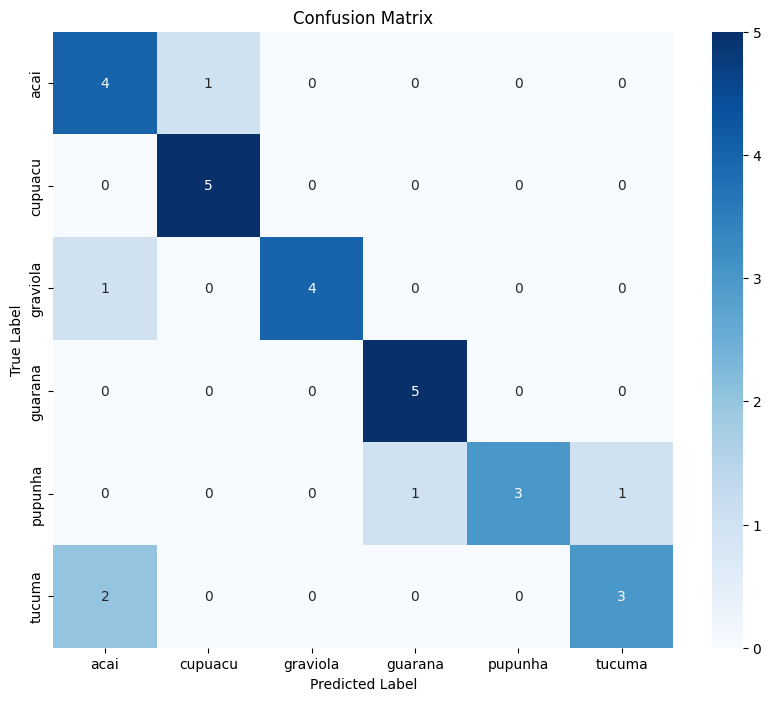

In [305]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

**3. Training vs Validation Accuracy & Loss Comparison**

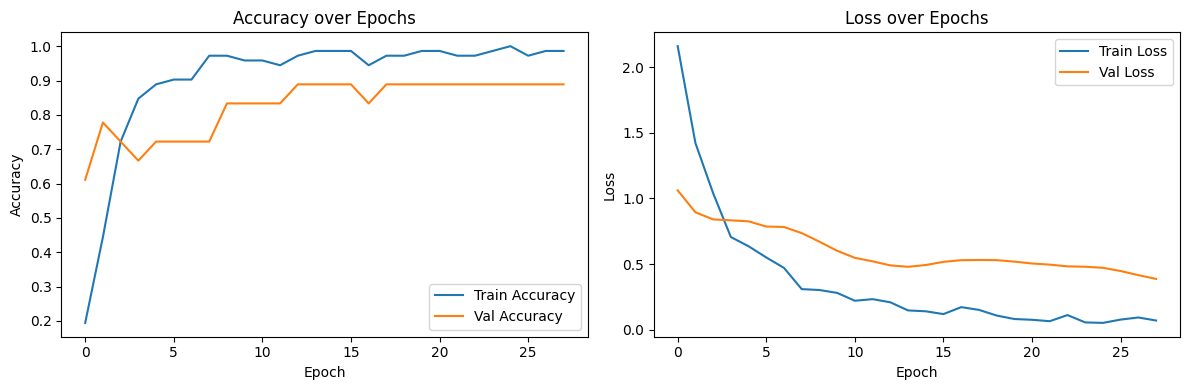

In [300]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.savefig('training_curves.png')  # save the figure
plt.show()

**4. Did the performance improved compared to training from scratch?**

The results show a clear improvement when using transfer learning compared to training the model from scratch.


The model trained from scratch achieved perfect training accuracy but suffered from severe overfitting, resulting in a low test accuracy of 43.33%. This indicates poor generalization despite strong performance on the training data.


In contrast, the transfer learning approach with a pre-trained base model, data augmentation, and regularization achieved more stable performance, with a validation accuracy of 88.89% and a significantly higher test accuracy of 80.00%.


Overall, transfer learning demonstrates substantially better generalization and robustness compared to training the model from scratch for this dataset.